# Stage 1: Load & Explore Data

In [3]:
#Import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")

In [5]:
#Load Dataset
df = pd.read_csv(
    "PS_20174392719_1491204439457_log.csv"
)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
#Basic Data Details
print(df.shape)

print(df.head())

print(df.info())

print(df.describe())

(6362620, 11)
   step      type    amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0     1   PAYMENT   9839.64  C1231006815       170136.0       160296.36   
1     1   PAYMENT   1864.28  C1666544295        21249.0        19384.72   
2     1  TRANSFER    181.00  C1305486145          181.0            0.00   
3     1  CASH_OUT    181.00   C840083671          181.0            0.00   
4     1   PAYMENT  11668.14  C2048537720        41554.0        29885.86   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0  M1979787155             0.0             0.0        0               0  
1  M2044282225             0.0             0.0        0               0  
2   C553264065             0.0             0.0        1               0  
3    C38997010         21182.0             0.0        1               0  
4  M1230701703             0.0             0.0        0               0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data column

In [9]:
#Check missing values
missing = (
    df.isnull()
      .sum()
      .sort_values(ascending=False)
)

print(missing)

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [11]:
#Check for duplicates
print(
    "Duplicates:",
    df.duplicated().sum()
)

Duplicates: 0


# Stage 2: Data Cleaning

In [14]:
df = df.drop_duplicates()

In [16]:
# Check fraud distribution
df["isFraud"].value_counts()

isFraud
0    6354407
1       8213
Name: count, dtype: int64

In [18]:
#Fraud Percentage
fraud_pct = (
    df["isFraud"].mean()
    * 100
)

print(
    f"Fraud Rate: {fraud_pct:.4f}%"
)

Fraud Rate: 0.1291%


In [20]:
#Transaction type
df["type"].value_counts()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64

# Stage 3: Feature Engineering

In [30]:
#Transaction Hour
df["hour"] = df["step"] % 24
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1


In [32]:
#Transaction Day
df["day"] = (
    df["step"] // 24
)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0


In [34]:
# Balance Difference
df["orig_balance_diff"] = (

    df["oldbalanceOrg"]
    -
    df["newbalanceOrig"]

)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,orig_balance_diff
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,9839.64
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,1864.28
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,181.00
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,181.00
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,11668.14


In [36]:
# Destination Balance Difference
df["dest_balance_diff"] = (

    df["newbalanceDest"]
    -
    df["oldbalanceDest"]

)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,orig_balance_diff,dest_balance_diff
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,9839.64,0.0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,1864.28,0.0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,181.00,0.0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,181.00,-21182.0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,11668.14,0.0


In [40]:
# High Value Transaction
threshold = (
    df["amount"]
    .quantile(0.95)
)

df["high_value_txn"] = np.where(

    df["amount"] > threshold,

    1,

    0

)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,orig_balance_diff,dest_balance_diff,high_value_txn
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,9839.64,0.0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,1864.28,0.0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,181.00,0.0,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,181.00,-21182.0,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,11668.14,0.0,0


In [47]:
#Customer type
df["origin_type"] = (
    df["nameOrig"]
    .str[0]
)

df["dest_type"] = (
    df["nameDest"]
    .str[0]
)
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,hour,day,orig_balance_diff,dest_balance_diff,high_value_txn,origin_type,dest_type
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0,1,0,9839.64,0.0,0,C,M
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0,1,0,1864.28,0.0,0,C,M
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0,1,0,181.00,0.0,0,C,C
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0,1,0,181.00,-21182.0,0,C,C
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0,1,0,11668.14,0.0,0,C,M


# Stage 4: EDA Dashboard

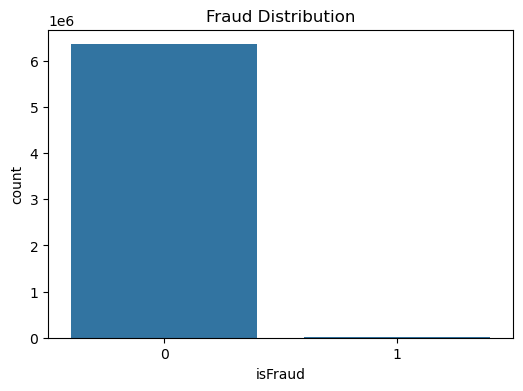

In [50]:
#Fraud Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    x="isFraud",
    data=df
)

plt.title(
    "Fraud Distribution"
)

plt.show()

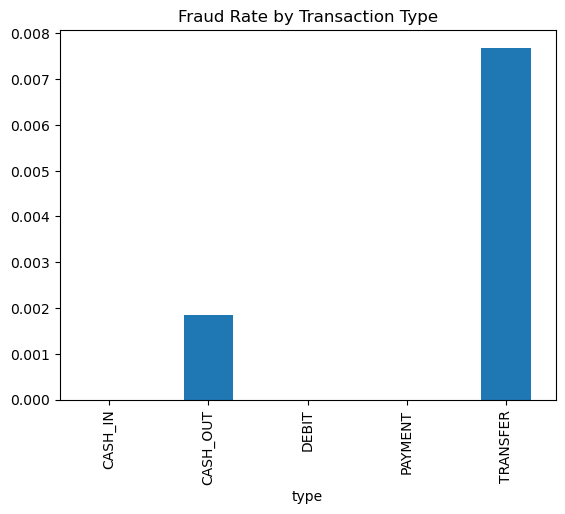

In [52]:
#Fraud by transaction type
fraud_type = (

    df.groupby("type")
      ["isFraud"]
      .mean()

)

fraud_type.plot(
    kind="bar"
)

plt.title(
    "Fraud Rate by Transaction Type"
)

plt.show()

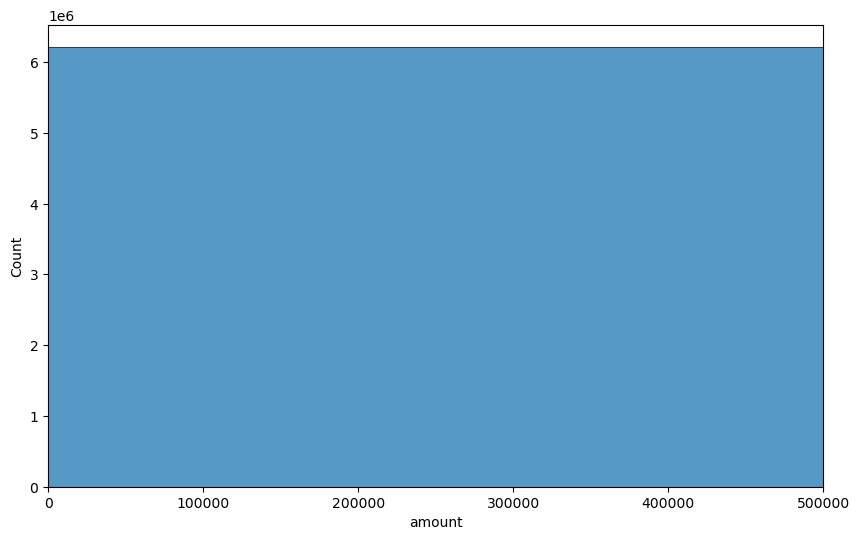

In [54]:
#Transaction amount distribution
plt.figure(figsize=(10,6))

sns.histplot(
    df["amount"],
    bins=100
)

plt.xlim(0,500000)

plt.show()

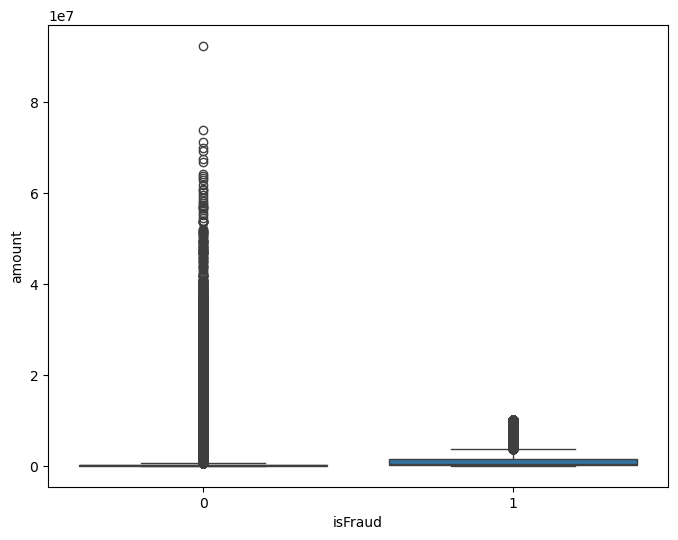

In [56]:
#Fraud vs Amount
plt.figure(figsize=(8,6))

sns.boxplot(

    x="isFraud",

    y="amount",

    data=df

)

plt.show()

<Axes: xlabel='hour'>

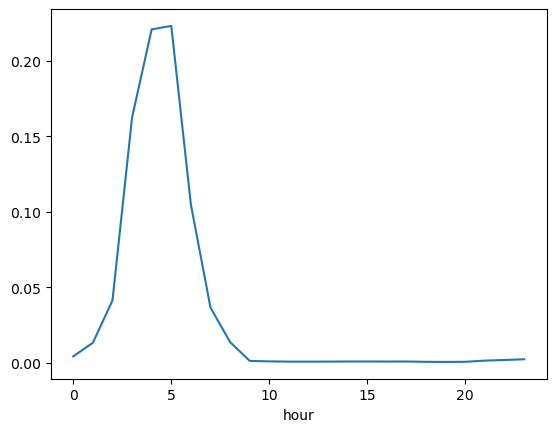

In [58]:
#Fraud by hour
hourly_fraud = (

    df.groupby("hour")
      ["isFraud"]
      .mean()

)

hourly_fraud.plot()

<Axes: xlabel='day'>

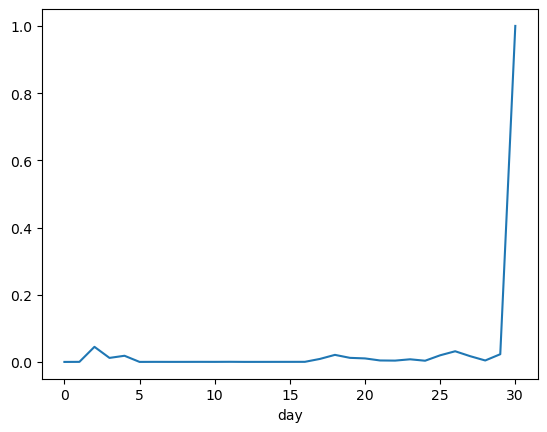

In [60]:
#Fraud by day
daily_fraud = (

    df.groupby("day")
      ["isFraud"]
      .mean()

)

daily_fraud.plot()

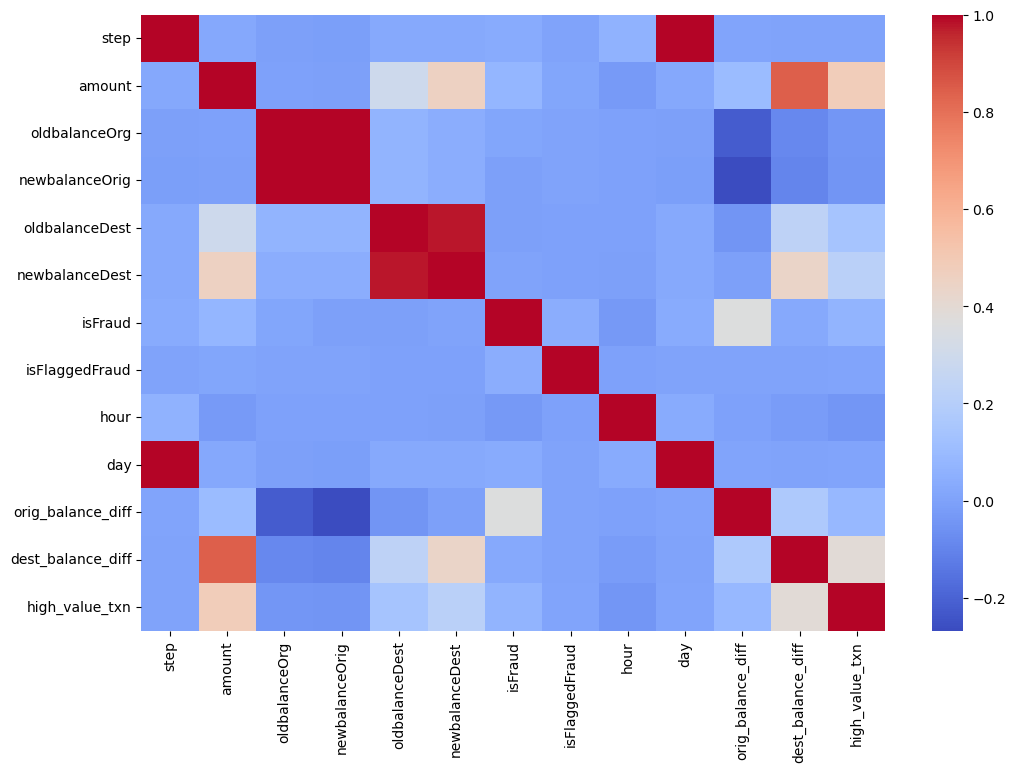

In [62]:
#Correlation Heatmap
numeric_cols = (
    df.select_dtypes(
        include=np.number
    )
)

plt.figure(
    figsize=(12,8)
)

sns.heatmap(

    numeric_cols.corr(),

    cmap="coolwarm"

)

plt.show()

# Stage 5: Deep Analysis

In [65]:
#Fraud Transaction types
fraud_summary = (

    df.groupby("type")
      .agg({

          "isFraud":"mean",

          "amount":"mean"

      })

)

print(fraud_summary)

           isFraud         amount
type                             
CASH_IN   0.000000  168920.242004
CASH_OUT  0.001840  176273.964346
DEBIT     0.000000    5483.665314
PAYMENT   0.000000   13057.604660
TRANSFER  0.007688  910647.009645


In [67]:
#Statistical Test
from scipy.stats import chi2_contingency
table = pd.crosstab(

    df["type"],

    df["isFraud"]

)

chi2,p,dof,expected = (

    chi2_contingency(table)

)

print(p)

0.0


Stage 6: Logistic Regression

In [70]:
#Target
y = df["isFraud"]

In [72]:
#Features
features = [

    "amount",

    "oldbalanceOrg",

    "newbalanceOrig",

    "oldbalanceDest",

    "newbalanceDest",

    "orig_balance_diff",

    "dest_balance_diff",

    "hour",

    "high_value_txn",

    "type"

]

In [74]:
X = df[features]

In [76]:
#One hot encoding
X = pd.get_dummies(

    X,

    columns=["type"],

    drop_first=True

)

In [78]:
#Train Test SPlit
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

In [80]:
#Scale Data
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

In [82]:
#Train model
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(

    max_iter=3000,

    random_state=42

)

log_model.fit(

    X_train_scaled,

    y_train

)

LogisticRegression(max_iter=3000, random_state=42)

In [84]:
#Predictions
y_pred = log_model.predict(
    X_test_scaled
)

y_prob = log_model.predict_proba(
    X_test_scaled
)[:,1]

In [86]:
#Evaluation
from sklearn.metrics import *

print(

    classification_report(

        y_test,

        y_pred

    )

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.91      0.48      0.62      1643

    accuracy                           1.00   1272524
   macro avg       0.95      0.74      0.81   1272524
weighted avg       1.00      1.00      1.00   1272524



In [88]:
#ROC AUC
roc_auc = roc_auc_score(

    y_test,

    y_prob

)

print(roc_auc)

0.9924655417161234


<Axes: >

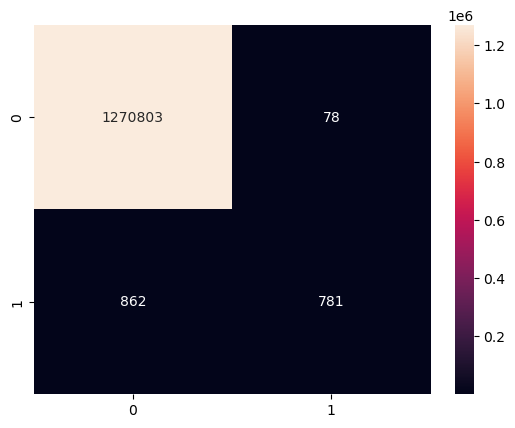

In [90]:
#Confusion matrix
cm = confusion_matrix(

    y_test,

    y_pred

)

sns.heatmap(

    cm,

    annot=True,

    fmt="d"

)

# Stage 7: Executive Insights

In [93]:
summary = pd.DataFrame({

    "Metric":[

        "Transactions",

        "Fraud Transactions",

        "Fraud Rate"

    ],

    "Value":[

        len(df),

        df["isFraud"].sum(),

        round(
            df["isFraud"].mean()*100,
            4
        )

    ]

})

summary

,Metric,Value
0,Transactions,6.362620e+06
1,Fraud Transactions,8.213000e+03
2,Fraud Rate,1.291000e-01
